## Weather Data : Initial Statistics

In [1]:
state="MA"

In [2]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib

In [3]:
%%time
%run lib/startup.py S

sc_type= S
10.41.226.219
namespace= grader-cse255-01
driver_host= 10.41.226.219


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


25/04/30 16:52:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/04/30 16:52:19 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
sparkContext= <SparkContext master=spark://spark-master-0.spark-headless.grader-cse255-01.svc.cluster.local:7077 appName=myapp>



/opt/bitnami/spark/python/pyspark/sql/context.py:112: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


version of ipwidgets= 8.1.6
parquet_root= /home/grader-cse255-01/public/Data/weather


measurements is a Dataframe (and table) with 12720632 records


stations is a Dataframe (and table) with 119503 records


weather is a Dataframe (and table) which is a join of measurements and stations with 12720632 records
CPU times: user 646 ms, sys: 104 ms, total: 750 ms
Wall time: 2min 58s


In [4]:
sc.defaultParallelism

24

In [5]:
from pyspark import SparkFiles
SparkFiles.getRootDirectory()

'/tmp/spark-88593b09-1be2-4aef-8936-35f7440eb903/userFiles-b2cd245a-1374-47ad-bf73-656675226cee'

In [6]:
import warnings  # Suppress Warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2 

# sc.setLogLevel("ERROR")

_figsize=(10,7)

## Read Data

### show 3 rows of joined weather+stations table

In [7]:
### Total number of stations
stations.count()

119503

### Find the states with the largest number of measurements

In [8]:
Query="""
from weather
select State, count(State) as count
WHERE Country = 'United States'
GROUP BY State
ORDER BY count DESC
"""

tmp=sqlContext.sql(Query).cache()
print(tmp.count())
tmp.show()

52
+-----+------+
|State| count|
+-----+------+
|   TX|498775|
|   CA|401007|
|   CO|313783|
|   MT|247802|
|   KS|239885|
|   OR|238437|
|   NY|218745|
|   NM|216304|
|   NE|216241|
|   IL|215148|
|   WA|209924|
|   PA|197154|
|   MI|190957|
|   MO|186909|
|   NC|185917|
|   AZ|184878|
|   WI|177188|
|   IA|171844|
|   UT|171246|
|   MN|171112|
+-----+------+
only showing top 20 rows



### Get information about NOAA data

In [9]:
!ls $parquet_root

dist2coastData	old		  weather-parquet     weather_statistics
noaa		stations-parquet  weather-statistics


In [10]:
!cat /home/grader-cse255-01/public/Data/weather/noaa/readme.txt

README FILE FOR DAILY GLOBAL HISTORICAL CLIMATOLOGY NETWORK (GHCN-DAILY) 
Version 3.28

--------------------------------------------------------------------------------
How to cite:

Note that the GHCN-Daily dataset itself now has a DOI (Digital Object Identifier)
so it may be relevant to cite both the methods/overview journal article as well 
as the specific version of the dataset used.

The journal article describing GHCN-Daily is:
Menne, M.J., I. Durre, R.S. Vose, B.E. Gleason, and T.G. Houston, 2012:  An overview 
of the Global Historical Climatology Network-Daily Database.  Journal of Atmospheric 
and Oceanic Technology, 29, 897-910, doi:10.1175/JTECH-D-11-00103.1.

To acknowledge the specific version of the dataset used, please cite:
Menne, M.J., I. Durre, B. Korzeniewski, S. McNeal, K. Thomas, X. Yin, S. Anthony, R. Ray, 
R.S. Vose, B.E.Gleason, and T.G. Houston, 2012: Global Historical Climatology Network - 
Daily (GHCN-Daily), Version 3. [indicate subset used following decimal

In [11]:
!grep TOBS /home/grader-cse255-01/public/Data/weather/noaa/readme.txt

 	   TOBS = Temperature at the time of observation (tenths of degrees C)


### Examples of SQL

In [12]:
## Find the number of measurements (years) for each station in state
Query="""
select Station,count(Station) as count
from weather
WHERE state='%s' and Measurement='TOBS'
GROUP BY Station
ORDER BY count DESC
"""%state
print(Query)


select Station,count(Station) as count
from weather
WHERE state='MA' and Measurement='TOBS'
GROUP BY Station
ORDER BY count DESC



In [13]:
tmp=sqlContext.sql(Query)
print(tmp.cache().count())
tmp.show(3)

160
+-----------+-----+
|    Station|count|
+-----------+-----+
|USC00194105|  122|
|USC00193505|  120|
|USC00198367|  107|
+-----------+-----+
only showing top 3 rows



###  Digging into a specific station

In [14]:
station="USC00431580"
Query="""
select * from stations
WHERE Station="%s"
"""%station
sqlContext.sql(Query).show()

+-----------+--------+---------+---------+----------+--------+-----+-------------+
|    station|latitude|longitude|elevation|dist2coast|    name|state|      country|
+-----------+--------+---------+---------+----------+--------+-----+-------------+
|USC00431580| 43.9572| -73.2106|    105.2|   222.875|CORNWALL|   VT|United States|
+-----------+--------+---------+---------+----------+--------+-----+-------------+



In [15]:
stations.where(stations.station=="USC00018380")\
.select(['station','name','state','country']).show()

+-----------+---------------+-----+-------------+
|    station|           name|state|      country|
+-----------+---------------+-----+-------------+
|USC00018380|TUSCALOOSA ACFD|   AL|United States|
+-----------+---------------+-----+-------------+



In [16]:
Query="""
SELECT Measurement,count(Measurement) as count 
FROM weather
WHERE Station='%s' 
GROUP BY Measurement
ORDER BY count DESC
"""%station
print('for station ',station)
sqlContext.sql(Query).show(8)

for station  USC00431580


+-----------+-----+
|Measurement|count|
+-----------+-----+
|       PRCP|  135|
|       SNOW|  128|
|       TMAX|  127|
|       TMIN|  127|
|       TOBS|  120|
|       SNWD|  103|
|       WT03|   61|
|       WT11|   51|
+-----------+-----+
only showing top 8 rows



In [17]:
%%time
Query="""
SELECT Year,count(Year) as count 
FROM weather
WHERE Station='%s' 
GROUP BY Year
ORDER BY count DESC
"""%station
pdf=sqlContext.sql(Query).toPandas()

pdf.head()

CPU times: user 25.1 ms, sys: 8.21 ms, total: 33.3 ms
Wall time: 3.38 s


,Year,count
0,1945,15
1,1946,14
2,1947,14
3,2004,13
4,1981,13


### Select a set of TOBS measurements

For all stations in state for a particular year

In [18]:
year=1945

Query="""
SELECT *
FROM weather
WHERE Year='%s' 
and Measurement='TOBS'
and State='%s'
"""%(year,state)
df=sqlContext.sql(Query).cache()
print('no. of answers=',df.count())
df.show(1)

no. of answers= 35
+-----------+-----------+----+--------------------+--------+---------+---------+----------+--------------------+-----+-------------+
|    Station|Measurement|Year|              Values|latitude|longitude|elevation|dist2coast|                name|state|      country|
+-----------+-----------+----+--------------------+--------+---------+---------+----------+--------------------+-----+-------------+
|USW00014703|       TOBS|1945|[43 00 D4 FF A7 F...|    42.2| -72.5333|     75.0|   97.3125|CHICOPEE FALLS WE...|   MA|United States|
+-----------+-----------+----+--------------------+--------+---------+---------+----------+--------------------+-----+-------------+
only showing top 1 row



In [19]:
!pwd

/home/grader-cse255-01/public/notebooks/Section2-PCA/PCA


In [20]:
from numpy_pack import unpackAndScale

In [21]:
ListOfRows=df.rdd.map(lambda x:(x.Station,unpackAndScale(x))).collect()

In [22]:
ListOfRows[0][0],ListOfRows[0][1][:9]

('USW00014703',
 array([  6.7,  -4.4,  -8.9,  -1.1,  -6.7, -12.2, -10. ,  -2.2,  -5.6],
       dtype=float16))

In [23]:
# make measurements into a vector
from numpy import *
_labels = [x[0] for x in ListOfRows]
M=stack([x[1] for x in ListOfRows])
M.shape


(35, 366)

## Compute statistics in memory
Without spark. This is a good idea when the matrix M is small (<100 rows)

### compute number of undefined in each row

In [24]:
#the number of nan's in each row
sum(np.isnan(M),axis=1)

array([ 72, 101,   1,   3,   9,  20,  13,  47,   4,   1,   2, 115,   1,
        19,   1,   3, 230, 274, 365,   4,   5,   8,   1,   1,   6,  70,
         1, 335,  83,  93, 280,  67,   2,   9,  15])

In [25]:
#the total number of nans
sum(np.isnan(M.flatten()))

2261

### Compute mean and std of all values (excluding NaNs)

In [26]:
G=array(M.flatten(),dtype=np.float64)
s1=np.nansum(G)
s2=np.nansum(G*G)
n=np.nansum(1-isnan(G))
print(s1,s2,n)

_mean =  s1/n
_var = s2/n-(s1/n)**2
_std=sqrt(_var)
print(f'mean={_mean}, std={_std}')

93731.55322265625 2074984.61719203 10549
mean=8.88534962770464, std=10.851277016049007


### Compute percentiles

In [27]:
def find_percentiles(SortedVals,percentile):
    L=int(len(SortedVals)/percentile)
    return SortedVals[L],SortedVals[-L]
  

In [28]:
Vals=M.flatten()
SortedVals=np.array(sorted(Vals))
low100,high100=find_percentiles(SortedVals,100)
low1000,high1000=find_percentiles(SortedVals,1000)
print(f'1-99 range[{low100},{high100}]')
print(f'0.1-99.9 range[{low1000},{high1000}]')

1-99 range[-1.7001953125,-4.3984375]
0.1-99.9 range[-11.703125,0.60009765625]


### Plotting TOBS for several stations, a single year

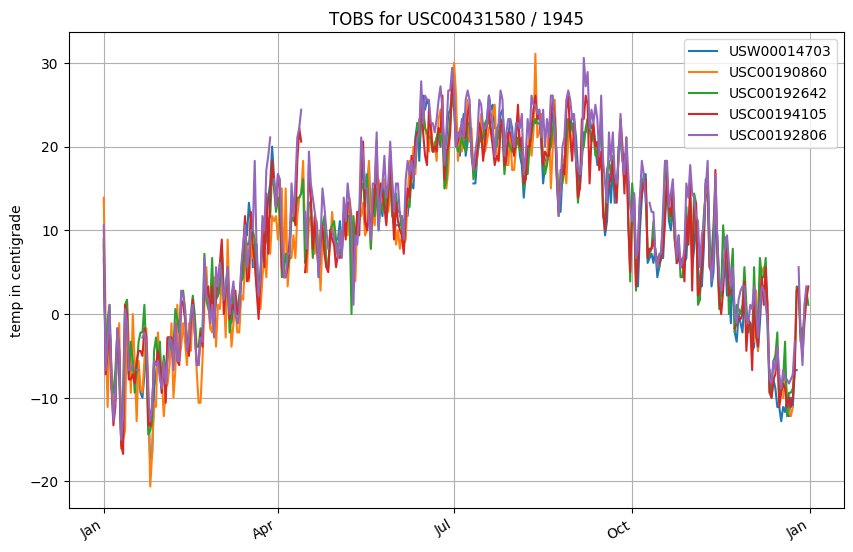

In [29]:
from lib.YearPlotter import YearPlotter
k=5
_title='TOBS for %s / %d'%(station,year)
fig, ax = plt.subplots(figsize=_figsize);
YP=YearPlotter()
YP.plot(M[:k,:366].T,fig,ax,title=_title,labels=_labels)# ,labels=labels);
plt.ylabel('temp in centigrade');

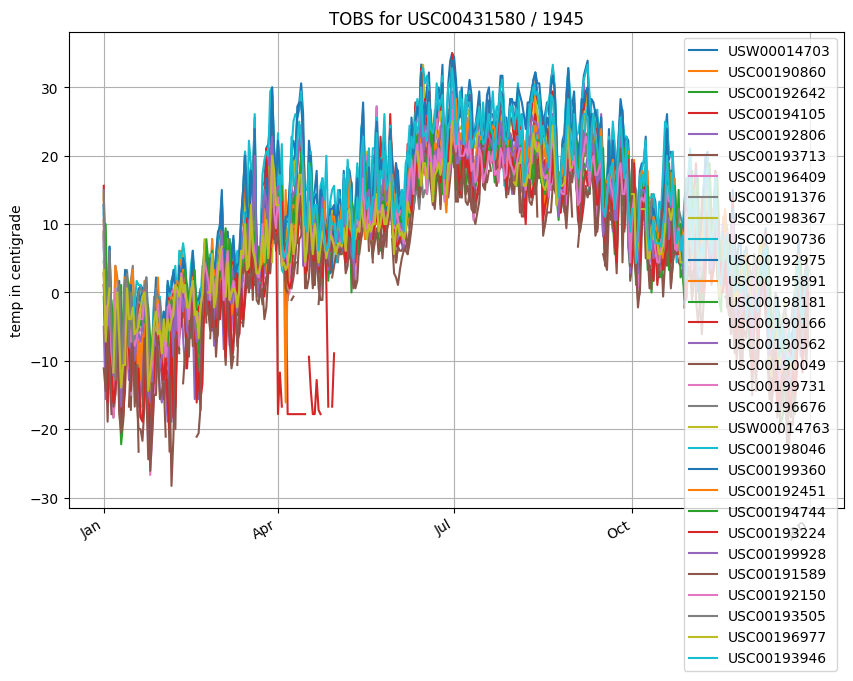

In [30]:
#looking at all of the year creates a mess
from lib.YearPlotter import YearPlotter
k=30
fig, ax = plt.subplots(figsize=_figsize);
YP=YearPlotter()
YP.plot(M[:k,:366].T,fig,ax,title=_title,labels=_labels)# ,labels=labels);
plt.ylabel('temp in centigrade');

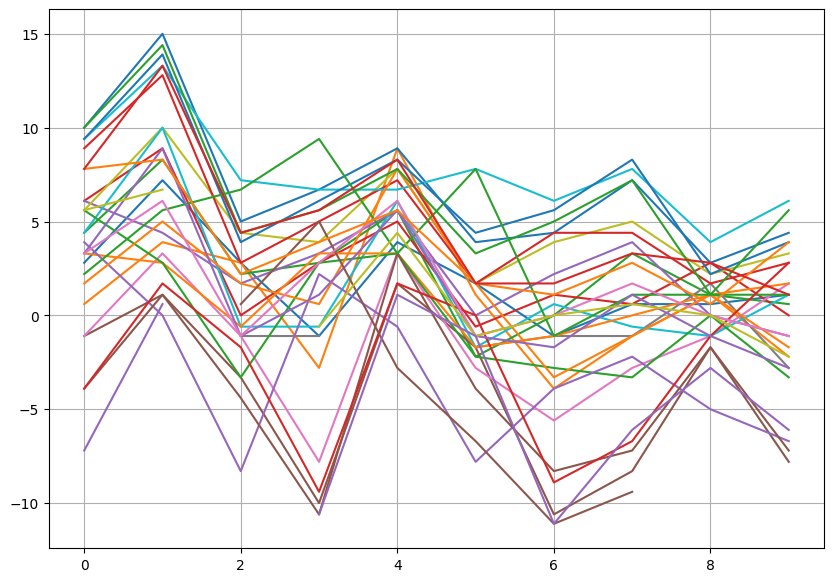

In [31]:
from matplotlib.pylab import *
## Looking at a small range of days  across all stations in state reveals 
## Interesting clustering
figure(figsize=_figsize)
plot(M[:,60:70].transpose());
grid()

In [32]:
year=2000
station, year

('USC00431580', 2000)

In [33]:

Query="""
SELECT *
FROM weather
WHERE Station='%s' 
and Year=%d
"""%(station,year )
print(Query)
pandas_df=sqlContext.sql(Query).toPandas()
pandas_df=pandas_df.set_index('Measurement')


SELECT *
FROM weather
WHERE Station='USC00431580' 
and Year=2000



In [34]:
pandas_df

,Station,Year,Values,latitude,longitude,elevation,dist2coast,name,state,country
Measurement,,,,,,,,,,
TMAX,USC00431580,2000,"[245, 255, 61, 0, 106, 0, 106, 0, 111, 0, 228,...",43.9572,-73.2106,105.2,222.875,CORNWALL,VT,United States
WT01,USC00431580,2000,"[25, 252, 25, 252, 25, 252, 25, 252, 25, 252, ...",43.9572,-73.2106,105.2,222.875,CORNWALL,VT,United States
SNOW,USC00431580,2000,"[0, 0, 0, 0, 0, 0, 13, 0, 0, 0, 0, 0, 0, 0, 8,...",43.9572,-73.2106,105.2,222.875,CORNWALL,VT,United States
SNWD,USC00431580,2000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",43.9572,-73.2106,105.2,222.875,CORNWALL,VT,United States
TOBS,USC00431580,2000,"[245, 255, 28, 0, 94, 0, 39, 0, 189, 255, 173,...",43.9572,-73.2106,105.2,222.875,CORNWALL,VT,United States
WT11,USC00431580,2000,"[25, 252, 25, 252, 25, 252, 25, 252, 25, 252, ...",43.9572,-73.2106,105.2,222.875,CORNWALL,VT,United States
TMIN,USC00431580,2000,"[134, 255, 239, 255, 28, 0, 239, 255, 189, 255...",43.9572,-73.2106,105.2,222.875,CORNWALL,VT,United States
WT03,USC00431580,2000,"[25, 252, 25, 252, 25, 252, 25, 252, 25, 252, ...",43.9572,-73.2106,105.2,222.875,CORNWALL,VT,United States
WT04,USC00431580,2000,"[25, 252, 25, 252, 1, 0, 25, 252, 25, 252, 25,...",43.9572,-73.2106,105.2,222.875,CORNWALL,VT,United States


### Temperature graphs

In [35]:
from lib.numpy_pack import unpackArray
_tobs=unpackArray(pandas_df.loc['TOBS','Values'])/10
_tmin=unpackArray(pandas_df.loc['TMIN','Values'])/10
_tmax=unpackArray(pandas_df.loc['TMAX','Values'])/10

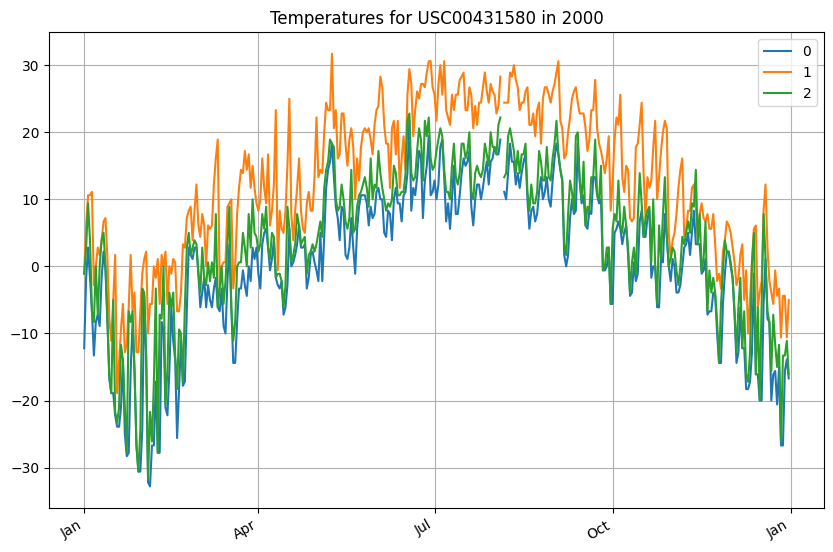

In [36]:
T=np.stack([_tmin,_tmax,_tobs])

fig, ax = plt.subplots(figsize=_figsize);
YP=YearPlotter()
YP.plot(T.transpose(),fig,ax,title='Temperatures for %s in %d'%(station,year));
plt.savefig('percipitation.png')
#title('A sample of graphs');

### viewing percipitation
Percipitation is very spiky, we can make it more manageable by smoothing.

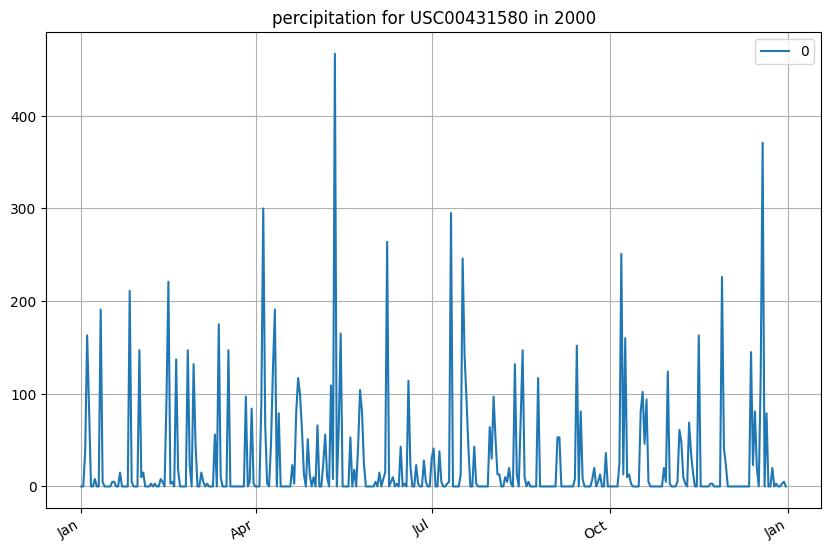

In [37]:
from lib.YearPlotter import YearPlotter 
from numpy_pack import unpackArray
T=np.stack([unpackArray(pandas_df.loc['PRCP','Values'],np.int16)])

fig, ax = plt.subplots(figsize=_figsize);
YP=YearPlotter()
YP.plot(T.transpose(),fig,ax,title='percipitation for %s in %d'%(station,year));
plt.savefig('percipitation.png')

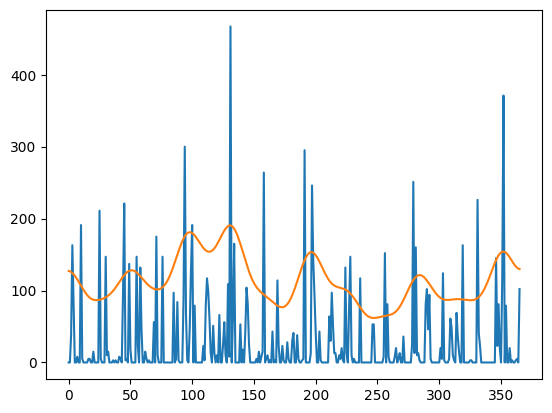

In [38]:
from scipy.ndimage import gaussian_filter1d
x=np.array(np.squeeze(T.T),dtype=np.float64)
plot(x)

# Apply Gaussian smoothing

x_filled = np.nan_to_num(x, nan=0.0)
mask = ~np.isnan(x)

# Smooth both the signal and the mask
sigma = 10
smoothed_signal = gaussian_filter1d(x_filled, sigma)

plot(smoothed_signal*4)


In [39]:
%%time
import os.path
from pickle import dump,load
ms=['TMAX', 'SNOW', 'SNWD', 'TMIN', 'PRCP', 'TOBS']

pkl_filename=parquet_root+'/weather-statistics/'+state+'-'+','.join(ms)+'.pkl'
print(pkl_filename)
!ls $pkl_filename
if os.path.isfile(pkl_filename):   
    print('precomputed statistics file exists')
    with open(pkl_filename,'br') as pkl_file:
        STAT=load(pkl_file)
else:
    print('No Statistics file, need to compute')
STAT.keys()

/home/grader-cse255-01/public/Data/weather/weather-statistics/MA-TMAX,SNOW,SNWD,TMIN,PRCP,TOBS.pkl
/home/grader-cse255-01/public/Data/weather/weather-statistics/MA-TMAX,SNOW,SNWD,TMIN,PRCP,TOBS.pkl
precomputed statistics file exists
CPU times: user 22.6 ms, sys: 36.6 ms, total: 59.2 ms
Wall time: 411 ms


dict_keys(['TMAX', 'SNOW', 'SNWD', 'TMIN', 'PRCP', 'TOBS'])

### Plots of mean and std of observations

In [40]:
from matplotlib.pylab import subplots,axis
def plot_pair(pair,func):
    """
    Create two side-by-side plots:
    pair
    """
    j=0
    fig,X=subplots(1,2,figsize=(16,6))
    axes=X.reshape(2)
    for m in pair:
        axis = axes[j]
        j+=1
        func(m,fig,axis)


def plot_mean_std(m,fig,axis):
    scale=1.
    temps=['TMIN','TMAX','TOBS']
    percipitation=['PRCP','SNOW','SNWD']
    _labels=['mean+std','mean','mean-std']
    if (m in percipitation):
        scale=10.
    mean=STAT[m]['Mean']/scale
    std=np.sqrt(STAT[m]['Var'])/scale
    graphs=np.vstack([mean+std,mean,mean-std]).transpose()
    YP.plot(graphs,fig,axis,labels=_labels,title='Mean+-std   '+m)
    if (m in temps):
        axis.set_ylabel('Degrees Celsius')
    if (m in percipitation):
        axis.set_ylabel('millimeter')



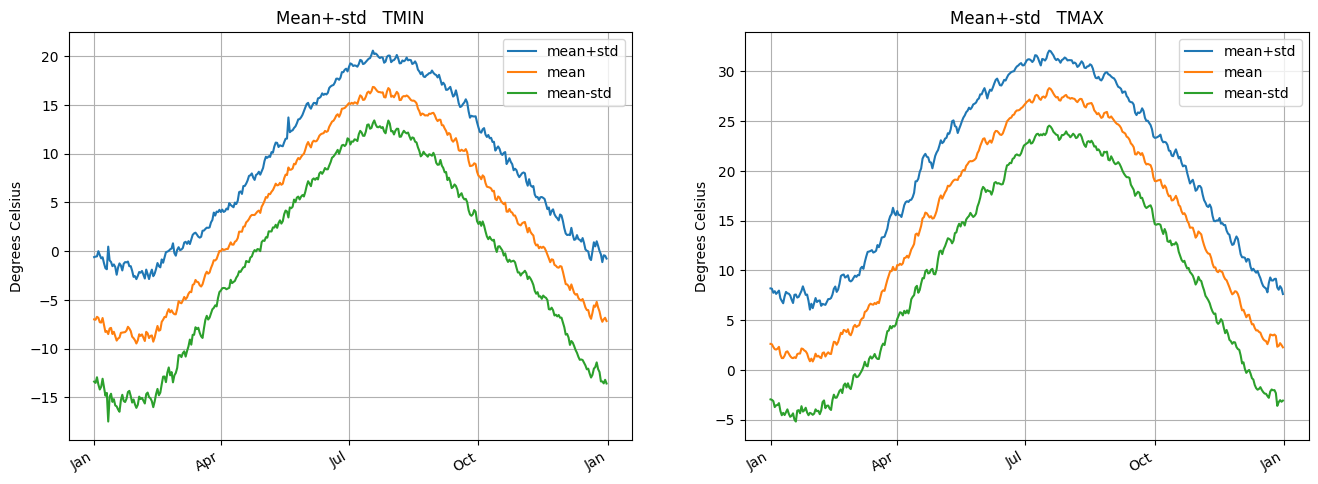

In [41]:
plot_pair(['TMIN','TMAX'],plot_mean_std)

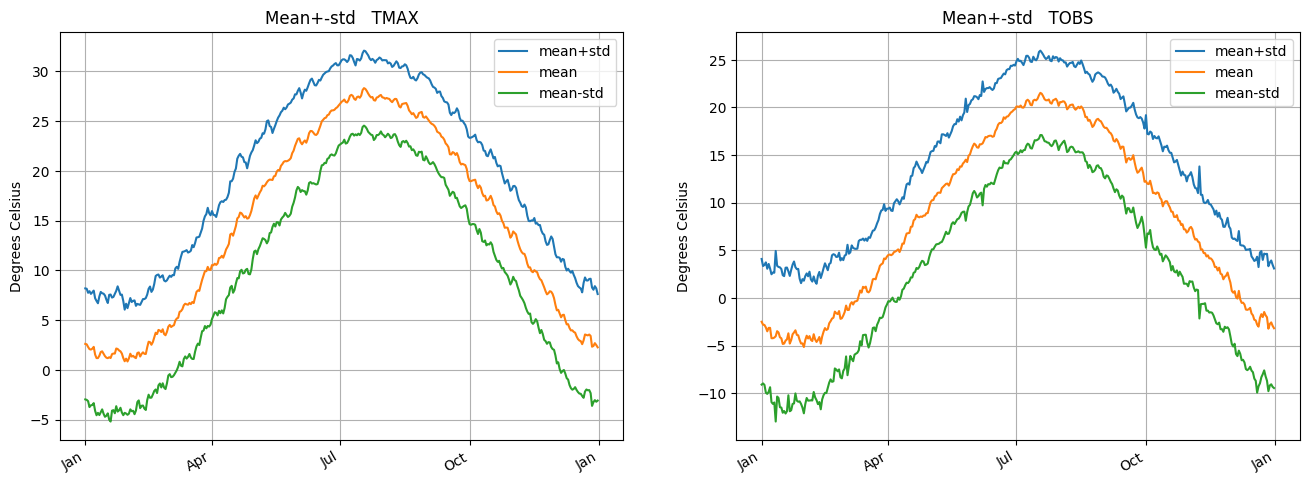

In [42]:
plot_pair(['TMAX','TOBS'],plot_mean_std)

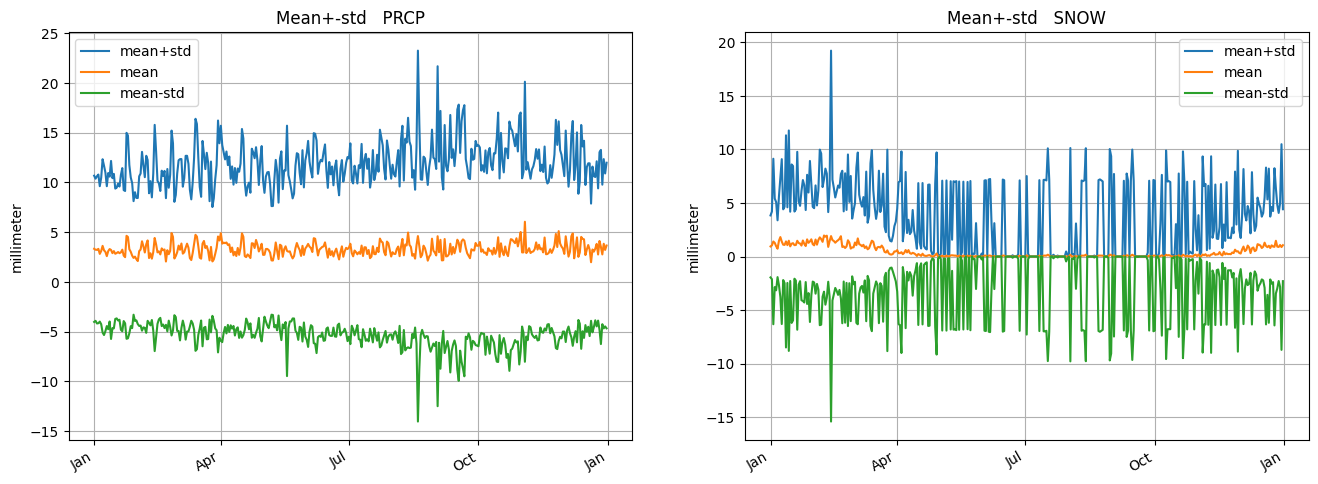

In [43]:
plot_pair(['PRCP','SNOW'],plot_mean_std)

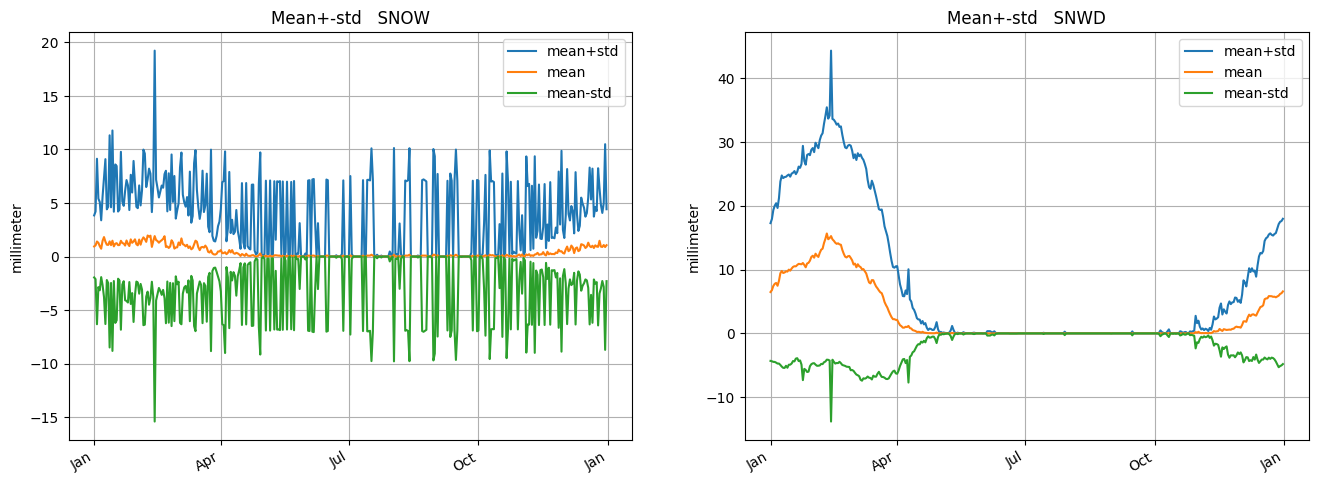

In [44]:
plot_pair(['SNOW', 'SNWD'],plot_mean_std)

## Distribution of missing observations

## Statistics across the state
The distribution of missing observations is not uniform throughout the year. We visualize it below.

In [45]:
from lib.MultiPlot import *
YP=YearPlotter()
def plot_valid(m,fig,axis):
    valid_m=STAT[m]['NE']
    YP.plot(valid_m,fig,axis,title='valid-counts '+m,label=m)

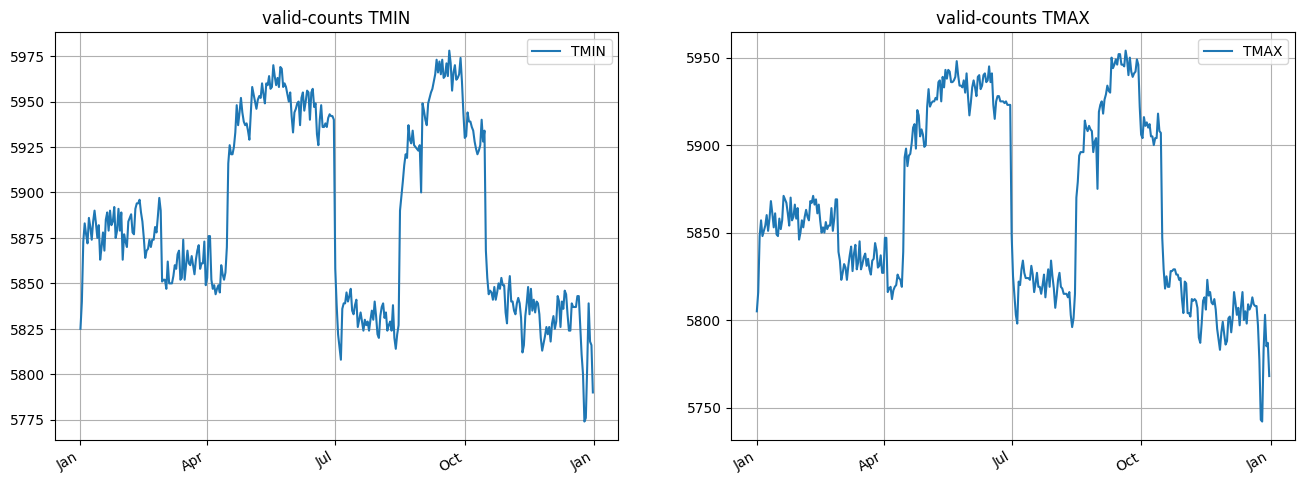

In [46]:
plot_pair(['TMIN','TMAX'],plot_valid)

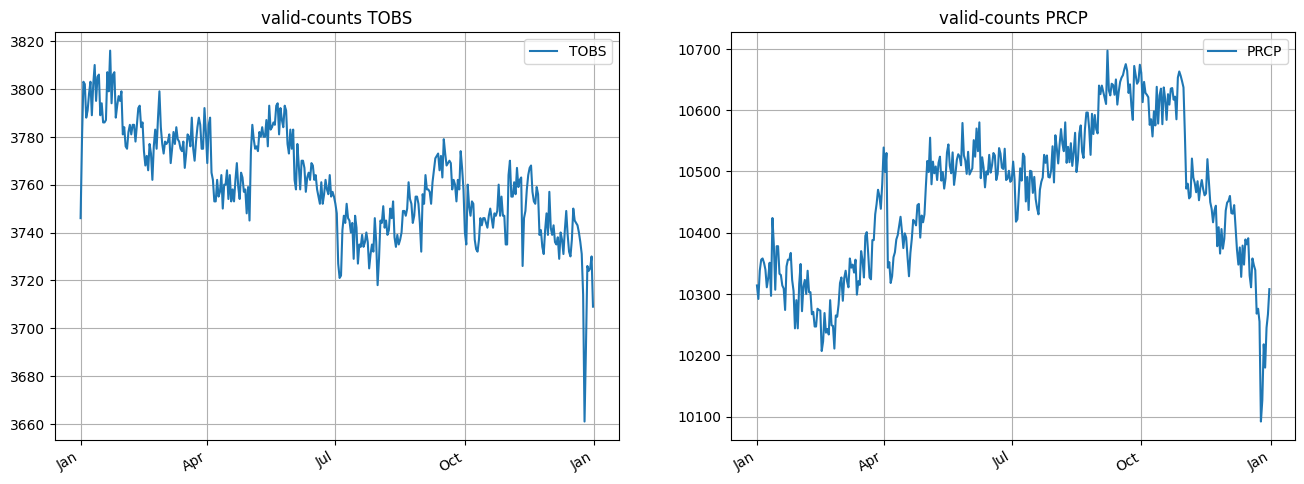

In [47]:
plot_pair(['TOBS','PRCP'],plot_valid)

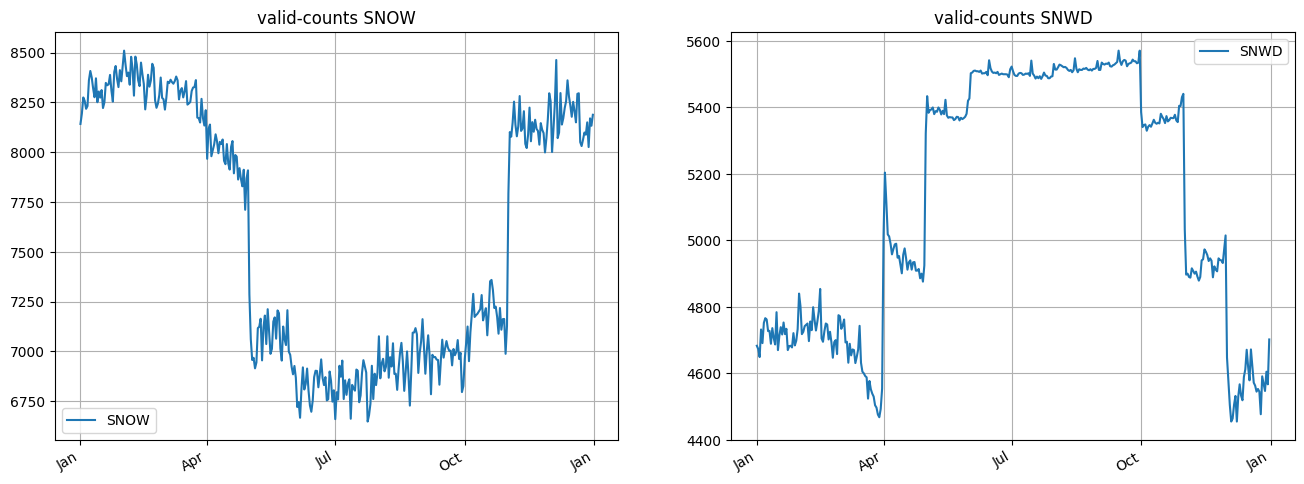

In [48]:

plot_pair(['SNOW', 'SNWD'],plot_valid)